In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
print("=" * 60)
print("  Netflix Movies & TV Shows – EDA")
print("  Using: titles.csv + credits.csv")
print("=" * 60)

  Netflix Movies & TV Shows – EDA
  Using: titles.csv + credits.csv


In [5]:
titles  = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')
 
print("\n[1] TITLES – First 5 rows:")
print(titles.head())
 
print("\n[2] CREDITS – First 5 rows:")
print(credits.head())
 
print("\n[3] Titles shape  :", titles.shape)
print("[4] Credits shape :", credits.shape)
 
print("\n[5] Titles columns :", titles.columns.tolist())
print("[6] Credits columns:", credits.columns.tolist())
 
print("\n[7] Titles info:")
print(titles.info())
 
print("\n[8] Credits info:")
print(credits.info())


[1] TITLES – First 5 rows:
         id                                title   type  \
0  ts300399  Five Came Back: The Reference Films   SHOW   
1   tm84618                          Taxi Driver  MOVIE   
2  tm154986                          Deliverance  MOVIE   
3  tm127384      Monty Python and the Holy Grail  MOVIE   
4  tm120801                      The Dirty Dozen  MOVIE   

                                         description  release_year  \
0  This collection includes 12 World War II-era p...          1945   
1  A mentally unstable Vietnam War veteran works ...          1976   
2  Intent on seeing the Cahulawassee River before...          1972   
3  King Arthur, accompanied by his squire, recrui...          1975   
4  12 American military prisoners in World War II...          1967   

  age_certification  runtime                                       genres  \
0             TV-MA       51                            ['documentation']   
1                 R      114              

In [25]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,unknown,unknown,unknown,0.6,unknown,NaN,NaN,NaN,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],unknown,tt0075314,8.2,808582.0,40.965,8.179,3748.0,Robert De Niro,Travis Bickle,ACTOR
2,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],unknown,tt0075314,8.2,808582.0,40.965,8.179,14658.0,Jodie Foster,Iris Steensma,ACTOR
3,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],unknown,tt0075314,8.2,808582.0,40.965,8.179,7064.0,Albert Brooks,Tom,ACTOR
4,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],unknown,tt0075314,8.2,808582.0,40.965,8.179,3739.0,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR


In [26]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78162 entries, 0 to 78161
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    78162 non-null  object 
 1   title                 78162 non-null  object 
 2   type                  78162 non-null  object 
 3   description           78162 non-null  object 
 4   release_year          78162 non-null  int64  
 5   age_certification     78162 non-null  object 
 6   runtime               78162 non-null  int64  
 7   genres                78162 non-null  object 
 8   production_countries  78162 non-null  object 
 9   seasons               78162 non-null  object 
 10  imdb_id               78162 non-null  object 
 11  imdb_score            78162 non-null  object 
 12  imdb_votes            78162 non-null  object 
 13  tmdb_popularity       78162 non-null  object 
 14  tmdb_score            78162 non-null  object 
 15  person_id          

In [27]:
df.isnull().sum()

id                        0
title                     0
type                      0
description               0
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                   0
imdb_score                0
imdb_votes                0
tmdb_popularity           0
tmdb_score                0
person_id               361
name                    361
character               361
role                    361
dtype: int64

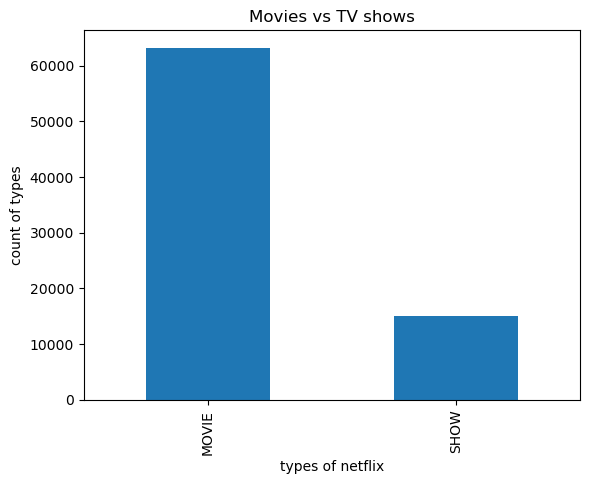

In [38]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV shows")
plt.xlabel("types of netflix")
plt.ylabel("count of types")
plt.show()

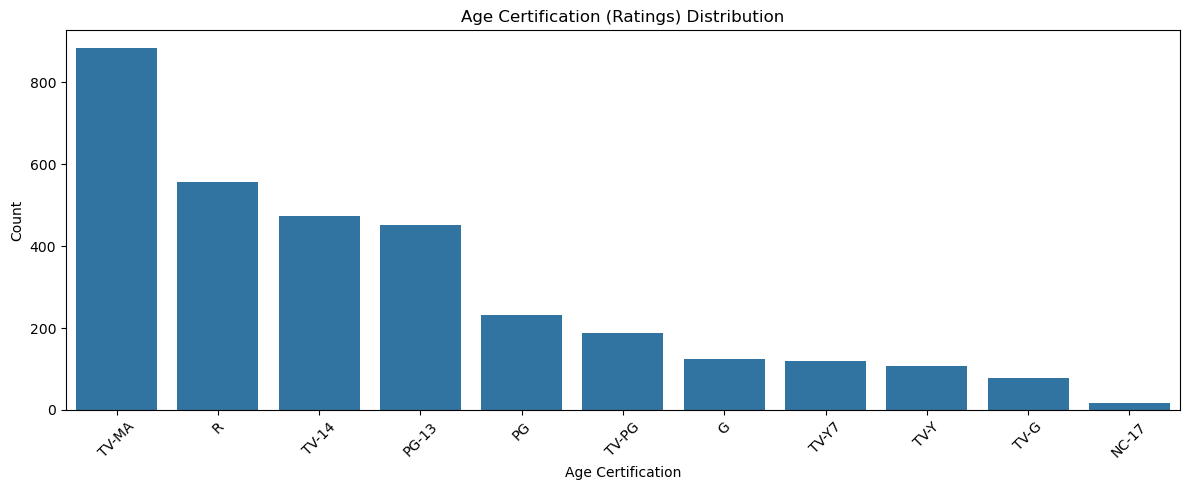

  -> Chart saved: 02_age_certification_distribution.png

[17] Age certification value counts:
age_certification
unknown    2619
TV-MA       883
R           556
TV-14       474
PG-13       451
PG          233
TV-PG       188
G           124
TV-Y7       120
TV-Y        107
TV-G         79
NC-17        16
Name: count, dtype: int64


In [40]:
plt.figure(figsize=(12, 5))
sns.countplot(
    x='age_certification',
    data=titles[titles['age_certification'] != 'unknown'],
    order=titles[titles['age_certification'] != 'unknown']['age_certification']
          .value_counts().index
)
plt.xticks(rotation=45)
plt.title("Age Certification (Ratings) Distribution")
plt.xlabel("Age Certification")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("02_age_certification_distribution.png", dpi=150)
plt.show()
print("  -> Chart saved: 02_age_certification_distribution.png")
 
print("\n[17] Age certification value counts:")
print(titles['age_certification'].value_counts())
 

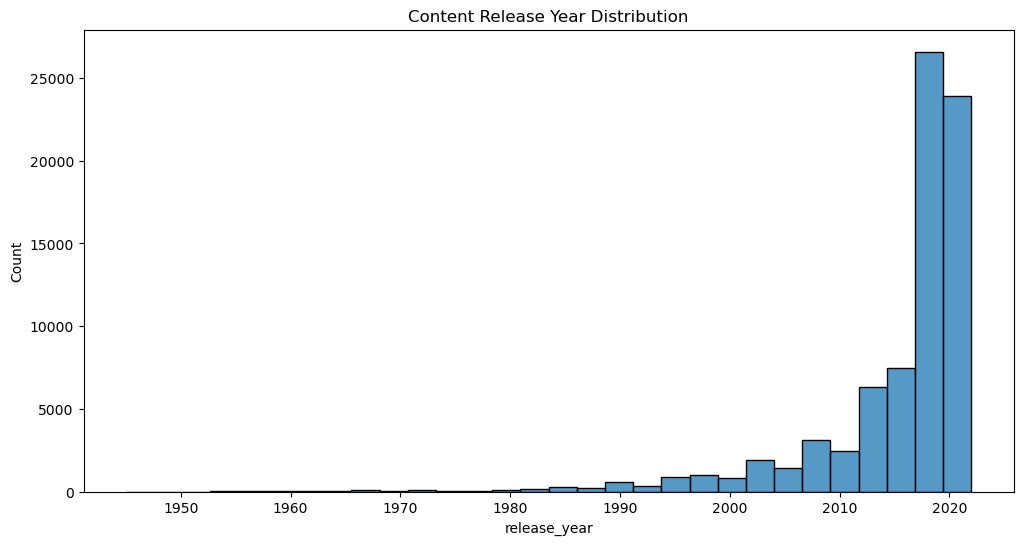

In [41]:
plt.figure(figsize=(12,6))
sns.histplot(df['release_year'],bins=30)
plt.title("Content Release Year Distribution")
plt.show()

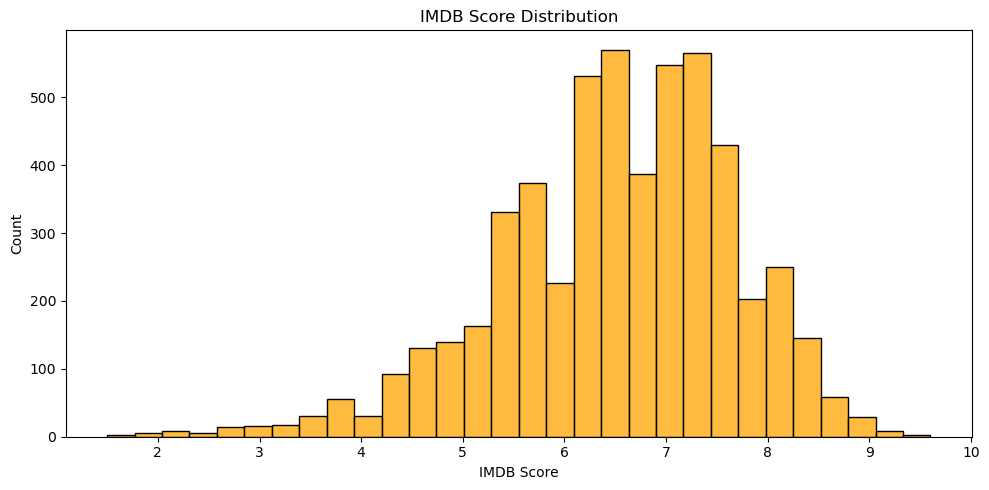

  -> Chart saved: 04_imdb_score_distribution.png

[18] IMDB Score statistics:
count    5368.000000
mean        6.510861
std         1.163826
min         1.500000
25%         5.800000
50%         6.600000
75%         7.300000
max         9.600000
Name: imdb_score, dtype: float64


In [12]:
imdb_data = titles[titles['imdb_score'] != 'unknown'].copy()
imdb_data['imdb_score'] = pd.to_numeric(imdb_data['imdb_score'], errors='coerce')
 
plt.figure(figsize=(10, 5))
sns.histplot(imdb_data['imdb_score'].dropna(), bins=30, color='orange')
plt.title("IMDB Score Distribution")
plt.xlabel("IMDB Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("04_imdb_score_distribution.png", dpi=150)
plt.show()
print("  -> Chart saved: 04_imdb_score_distribution.png")
 
print("\n[18] IMDB Score statistics:")
print(imdb_data['imdb_score'].describe())
 

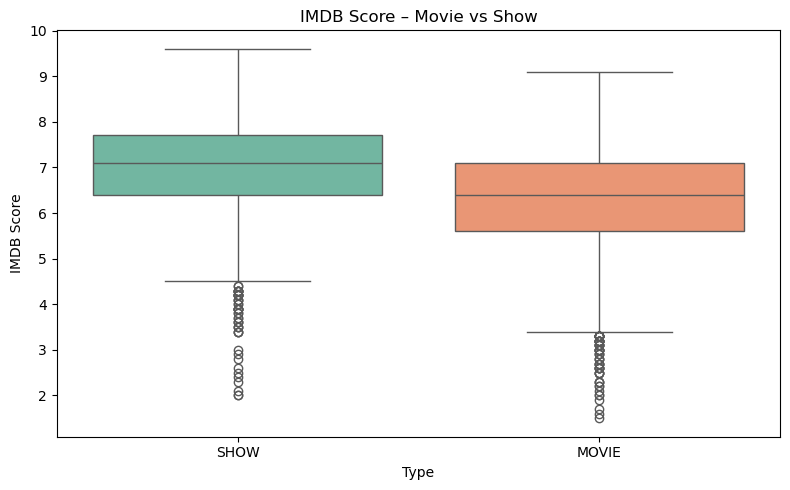

-> Chart saved: 05_imdb_score_movie_vs_show.png


In [42]:
imdb_data2 = titles[titles['imdb_score'] != 'unknown'].copy()
imdb_data2['imdb_score'] = pd.to_numeric(imdb_data2['imdb_score'], errors='coerce')

plt.figure(figsize=(8, 5))
sns.boxplot(x='type', y='imdb_score', hue='type', data=imdb_data2, palette='Set2', legend=False)

plt.title("IMDB Score – Movie vs Show")
plt.xlabel("Type")
plt.ylabel("IMDB Score")

plt.tight_layout()
plt.savefig("05_imdb_score_movie_vs_show.png", dpi=150)
plt.show()

print("-> Chart saved: 05_imdb_score_movie_vs_show.png")


[19] Movie runtime statistics:
count    3744.000000
mean       98.213675
std        30.640640
min         2.000000
25%        85.000000
50%        98.000000
75%       115.000000
max       240.000000
Name: runtime, dtype: float64


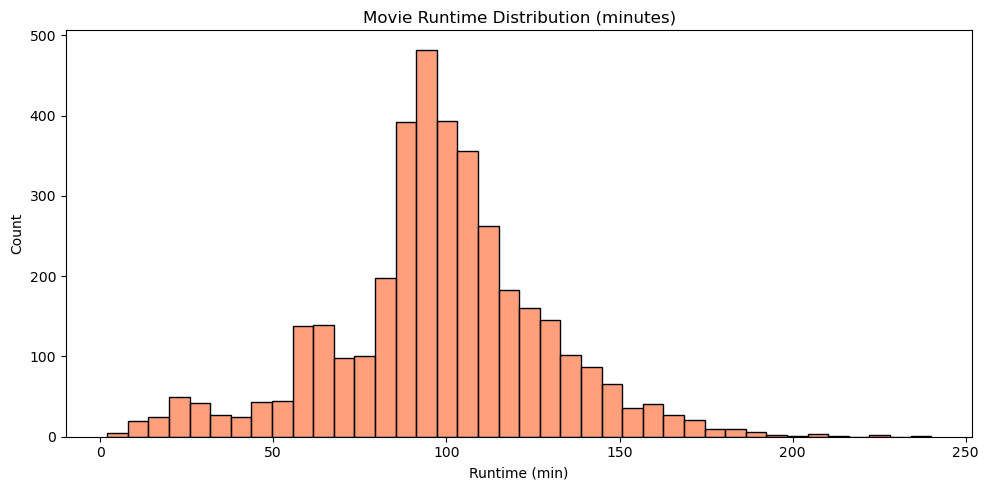

  -> Chart saved: 06_movie_runtime_distribution.png


In [43]:
movies = titles[titles['type'] == 'MOVIE'].copy()
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')
 
print("\n[19] Movie runtime statistics:")
print(movies['runtime'].describe())
 
plt.figure(figsize=(10, 5))
sns.histplot(movies['runtime'].dropna(), bins=40, color='coral')
plt.title("Movie Runtime Distribution (minutes)")
plt.xlabel("Runtime (min)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("06_movie_runtime_distribution.png", dpi=150)
plt.show()
print("  -> Chart saved: 06_movie_runtime_distribution.png")

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

titles = pd.read_csv("titles.csv")   # or your dataset file name

In [45]:
print(type(titles))

<class 'pandas.core.frame.DataFrame'>



[20] Top 10 production countries:
primary_country
US    2084
IN     610
GB     296
JP     273
KR     224
ES     182
CA     176
FR     167
MX     111
BR      96
Name: count, dtype: int64


C:\Users\saksh\AppData\Local\Temp\ipykernel_26848\17390422.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


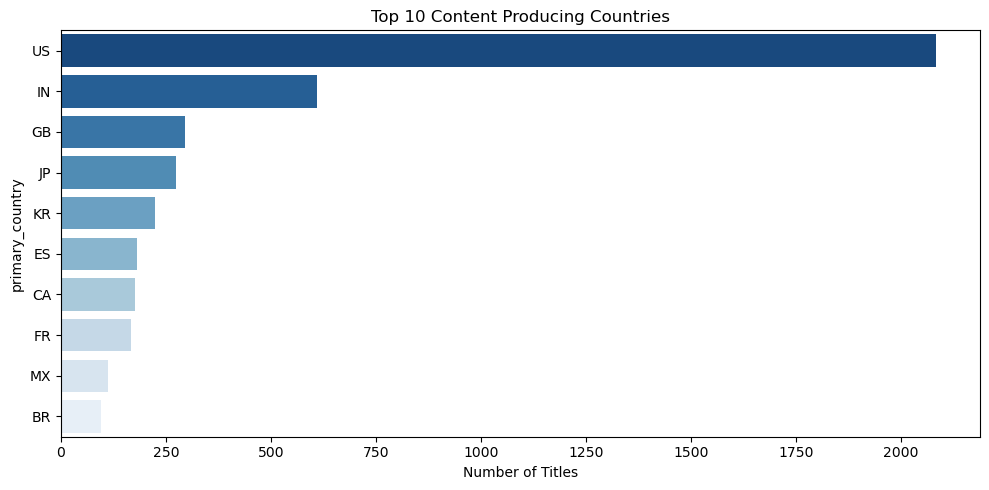

  -> Chart saved: 07_top10_countries.png


In [46]:
titles['primary_country'] = (
    titles['production_countries']
    .str.replace(r"[\[\]' ]", "", regex=True)
    .str.split(',')
    .str[0]
)

top_countries = (
    titles[titles['primary_country'] != '']
    ['primary_country'].value_counts().head(10)
)

print("\n[20] Top 10 production countries:")
print(top_countries)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("07_top10_countries.png", dpi=150)
plt.show()
print("  -> Chart saved: 07_top10_countries.png")




[21] Top 10 genres:
genres
drama            2968
comedy           2325
thriller         1228
action           1157
romance           971
documentation     952
crime             936
animation         705
family            682
fantasy           630
Name: count, dtype: int64


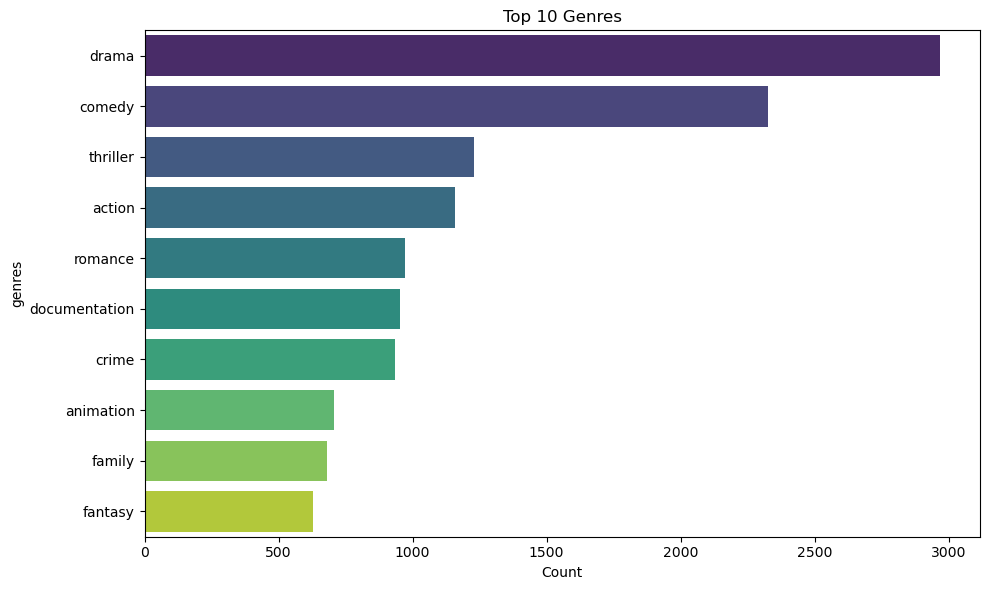

-> Chart saved: 08_top10_genres.png


In [47]:
titles_genres = titles.copy()
titles_genres['genres'] = (
    titles_genres['genres']
    .str.replace(r"[\[\]' ]", "", regex=True)
    .str.split(',')
)

genres_exploded = titles_genres.explode('genres')
genres_exploded['genres'] = genres_exploded['genres'].str.strip()

top_genres = (
    genres_exploded[genres_exploded['genres'] != '']
    ['genres'].value_counts().head(10)
)

print("\n[21] Top 10 genres:")
print(top_genres)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)

plt.title("Top 10 Genres")
plt.xlabel("Count")

plt.tight_layout()
plt.savefig("08_top10_genres.png", dpi=150)
plt.show()

print("-> Chart saved: 08_top10_genres.png")

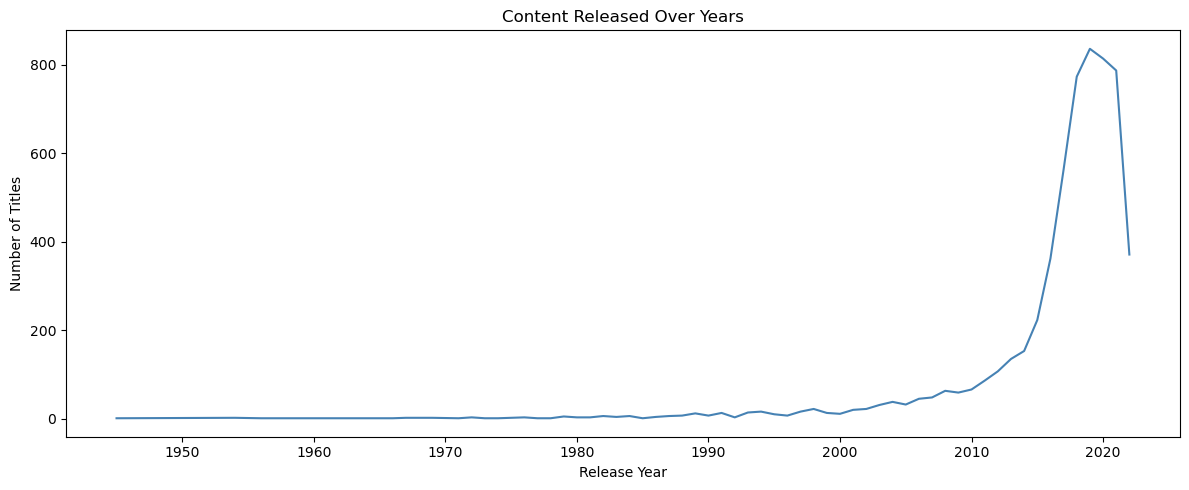

  -> Chart saved: 09_content_over_years.png


In [48]:
release_trend = titles.groupby('release_year').size()

release_trend.plot(kind='line', figsize=(12, 5), color='steelblue')
plt.title("Content Released Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("09_content_over_years.png", dpi=150)
plt.show()
print("  -> Chart saved: 09_content_over_years.png")



[22] Role distribution in credits:
role
ACTOR       73251
DIRECTOR     4550
Name: count, dtype: int64


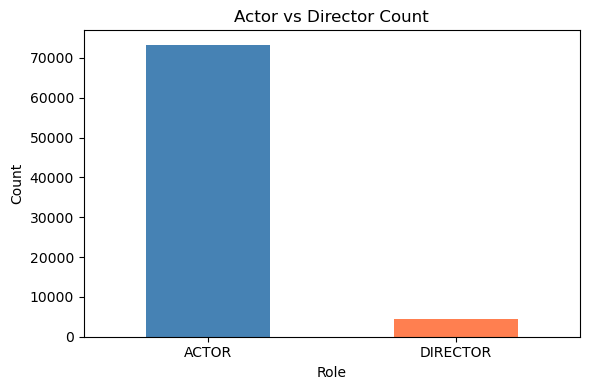

  -> Chart saved: 10_actor_vs_director.png


In [49]:
print("\n[22] Role distribution in credits:")
print(credits['role'].value_counts())

plt.figure(figsize=(6, 4))
credits['role'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Actor vs Director Count")
plt.xlabel("Role")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("10_actor_vs_director.png", dpi=150)
plt.show()
print("  -> Chart saved: 10_actor_vs_director.png")


In [50]:
print(type(credits))

<class 'pandas.core.frame.DataFrame'>


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

credits = pd.read_csv("credits.csv")


[23] Top 10 most appearing actors:
name
Boman Irani              25
Kareena Kapoor Khan      25
Shah Rukh Khan           23
Takahiro Sakurai         21
Priyanka Chopra Jonas    20
Amitabh Bachchan         20
Paresh Rawal             20
Nawazuddin Siddiqui      19
Anupam Kher              19
Junichi Suwabe           19
Name: count, dtype: int64


C:\Users\saksh\AppData\Local\Temp\ipykernel_26848\3912632565.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma')


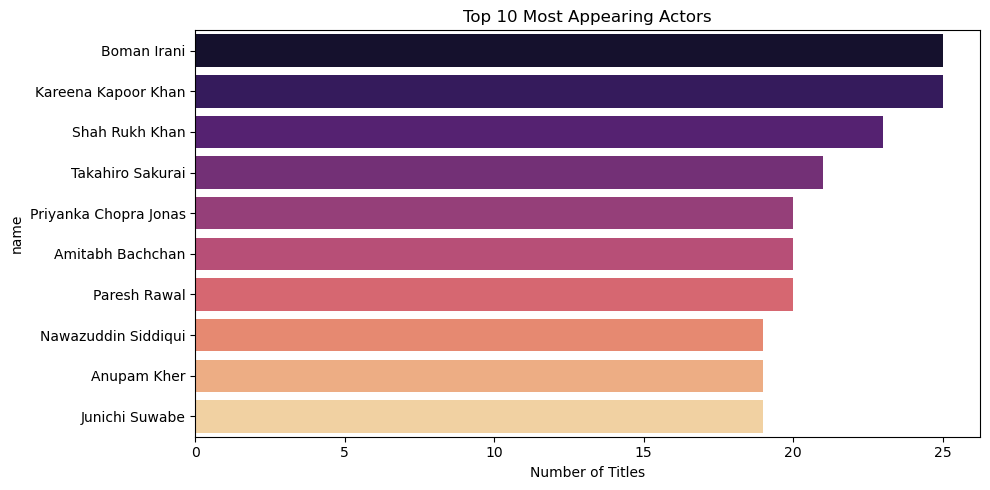

  -> Chart saved: 11_top10_actors.png


In [52]:
actors = credits[credits['role'] == 'ACTOR']
top_actors = actors['name'].value_counts().head(10)

print("\n[23] Top 10 most appearing actors:")
print(top_actors)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma')
plt.title("Top 10 Most Appearing Actors")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("11_top10_actors.png", dpi=150)
plt.show()
print("  -> Chart saved: 11_top10_actors.png")



[24] Top 10 most appearing directors:
name
Raúl Campos            20
Jan Suter              19
Ryan Polito            17
Jay Karas              15
Marcus Raboy           14
Jay Chapman            12
Cathy Garcia-Molina    12
Youssef Chahine        11
Suhas Kadav             8
Justin G. Dyck          8
Name: count, dtype: int64


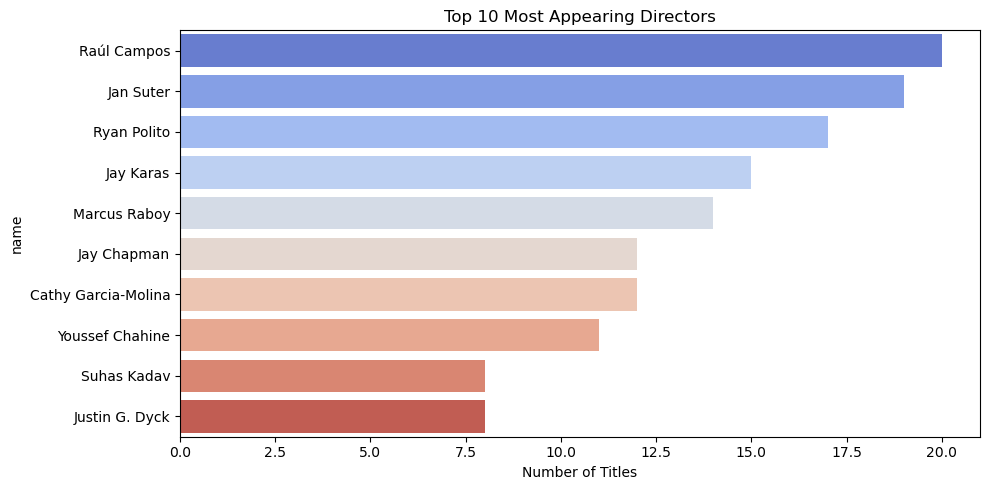

-> Chart saved: 12_top10_directors.png


In [53]:
directors = credits[credits['role'] == 'DIRECTOR']
top_directors = directors['name'].value_counts().head(10)

print("\n[24] Top 10 most appearing directors:")
print(top_directors)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette='coolwarm', legend=False)

plt.title("Top 10 Most Appearing Directors")
plt.xlabel("Number of Titles")

plt.tight_layout()
plt.savefig("12_top10_directors.png", dpi=150)
plt.show()

print("-> Chart saved: 12_top10_directors.png")

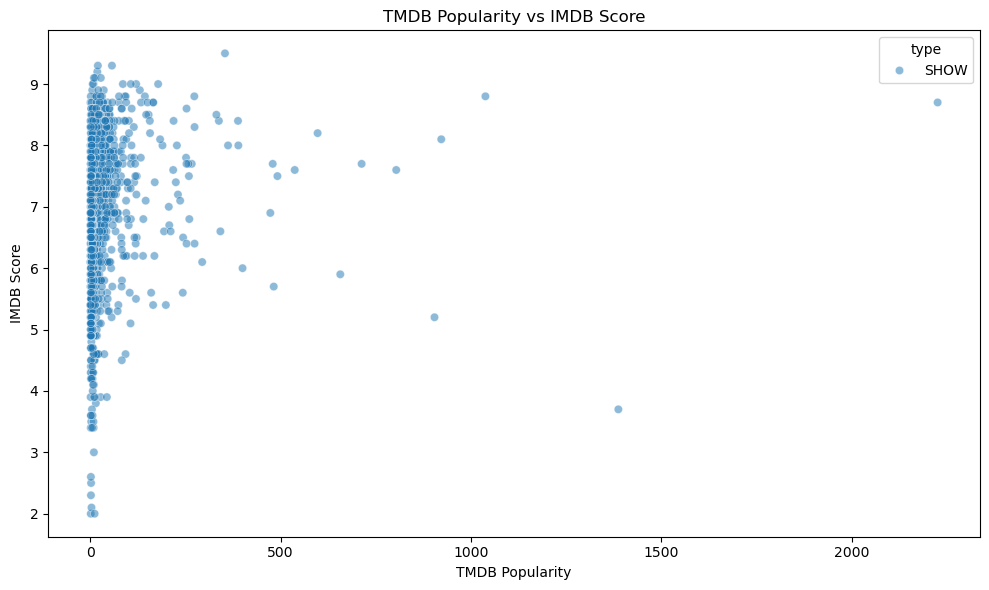

  -> Chart saved: 13_tmdb_vs_imdb.png


In [54]:
scatter_df = titles[
    (titles['imdb_score']      != 'unknown') &
    (titles['tmdb_popularity'] != 'unknown')
].copy()
scatter_df['imdb_score']      = pd.to_numeric(scatter_df['imdb_score'],      errors='coerce')
scatter_df['tmdb_popularity'] = pd.to_numeric(scatter_df['tmdb_popularity'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='tmdb_popularity', y='imdb_score',
    hue='type', data=scatter_df.dropna(), alpha=0.5
)
plt.title("TMDB Popularity vs IMDB Score")
plt.xlabel("TMDB Popularity")
plt.ylabel("IMDB Score")
plt.tight_layout()
plt.savefig("13_tmdb_vs_imdb.png", dpi=150)
plt.show()
print("  -> Chart saved: 13_tmdb_vs_imdb.png")



[25] TV Show seasons statistics:
count    2106.000000
mean        2.162868
std         2.689041
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        42.000000
Name: seasons, dtype: float64


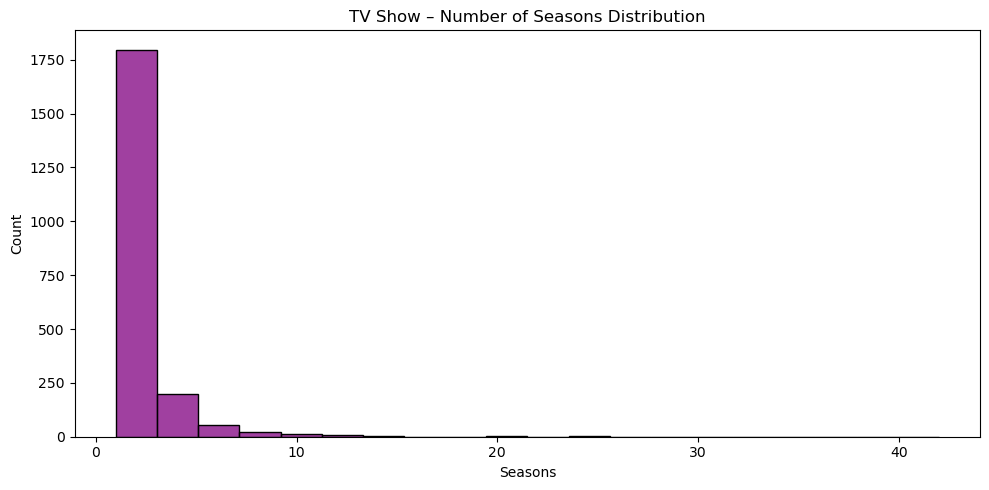

  -> Chart saved: 14_tvshow_seasons.png


In [55]:
shows = titles[titles['type'] == 'SHOW'].copy()
shows['seasons'] = pd.to_numeric(shows['seasons'], errors='coerce')

print("\n[25] TV Show seasons statistics:")
print(shows['seasons'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(shows['seasons'].dropna(), bins=20, color='purple')
plt.title("TV Show – Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("14_tvshow_seasons.png", dpi=150)
plt.show()
print("  -> Chart saved: 14_tvshow_seasons.png")


In [56]:
top_rated = titles[titles['imdb_score'] != 'unknown'].copy()
top_rated['imdb_score'] = pd.to_numeric(top_rated['imdb_score'], errors='coerce')
top_rated = (
    top_rated[['title', 'type', 'imdb_score', 'release_year']]
    .dropna()
    .sort_values('imdb_score', ascending=False)
    .head(10)
)

print("\n[26] Top 10 highest IMDB rated titles:")
print(top_rated.to_string(index=False))




[26] Top 10 highest IMDB rated titles:
                            title  type  imdb_score  release_year
                         #ABtalks  SHOW         9.6          2018
                         Khawatir  SHOW         9.5          2005
                     Breaking Bad  SHOW         9.5          2008
       Avatar: The Last Airbender  SHOW         9.3          2005
                       Our Planet  SHOW         9.3          2019
                       Reply 1988  SHOW         9.2          2015
Chhota Bheem & Krishna vs Zimbara MOVIE         9.1          2013
                            Major MOVIE         9.1          2022
                     Kota Factory  SHOW         9.1          2019
                   The Last Dance  SHOW         9.1          2020


In [57]:
print("\n" + "=" * 60)
print("  KEY INSIGHTS")
print("=" * 60)
print("""
1. Movies dominate Netflix content compared to TV Shows.
2. The United States produces the highest amount of content.
3. TV-MA / TV-14 are the most common age certifications.
4. Content growth significantly increased after 2015.
5. Drama and Comedy are the most common genres.
6. Most movies have a runtime between 80 and 120 minutes.
7. Most TV shows have only 1 season.
8. IMDB scores mostly range between 6 and 8.
""")

print("=" * 60)
print("  CONCLUSION")
print("=" * 60)
print("""
The analysis of the titles and credits datasets reveals
Netflix's strong focus on movies and international content
expansion after 2015. The platform heavily invests in
mature-rated content and diverse genres to target global
audiences. Drama leads across both movies and TV shows,
and the US remains the top content-producing country.
""")

print("\nAll 14 charts saved as PNG files in the current directory.")
print("EDA complete!")


  KEY INSIGHTS

1. Movies dominate Netflix content compared to TV Shows.
2. The United States produces the highest amount of content.
3. TV-MA / TV-14 are the most common age certifications.
4. Content growth significantly increased after 2015.
5. Drama and Comedy are the most common genres.
6. Most movies have a runtime between 80 and 120 minutes.
7. Most TV shows have only 1 season.
8. IMDB scores mostly range between 6 and 8.

  CONCLUSION

The analysis of the titles and credits datasets reveals
Netflix's strong focus on movies and international content
expansion after 2015. The platform heavily invests in
mature-rated content and diverse genres to target global
audiences. Drama leads across both movies and TV shows,
and the US remains the top content-producing country.


All 14 charts saved as PNG files in the current directory.
EDA complete!
